In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

In [37]:
sleep_df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
sleep_df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [38]:
sleep_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [39]:
sleep_df.isnull().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

In [40]:
sleep_df.dropna()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
16,17,Female,29,Nurse,6.5,5,40,7,Normal Weight,132/87,80,4000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [41]:
missing_values_after_drop_sleep = sleep_df.isnull().sum()

In [42]:
summary_stats_sleep = sleep_df.describe()
summary_stats_sleep

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


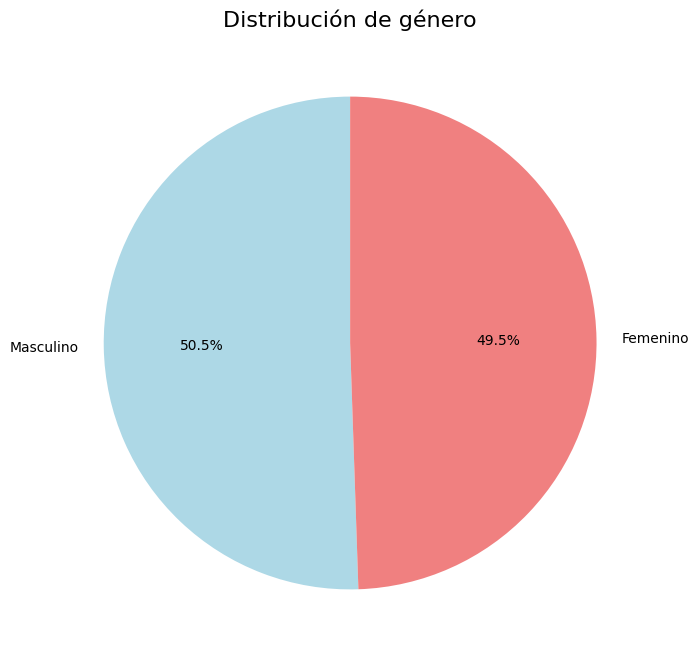

In [43]:
plt.figure(figsize=(8, 8))
sleep_df['Gender'] = sleep_df['Gender'].replace({
    'Male': 'Masculino',
    'Female': 'Femenino'
})

gender_counts = sleep_df['Gender'].value_counts()

plt.pie(gender_counts, 
        labels=gender_counts.index, 
        autopct='%1.1f%%', 
        colors=['lightblue', 'lightcoral'], 
        startangle=90)

plt.title('Distribución de género', fontsize=16)
plt.savefig('gender_distribution.pdf')
plt.show()


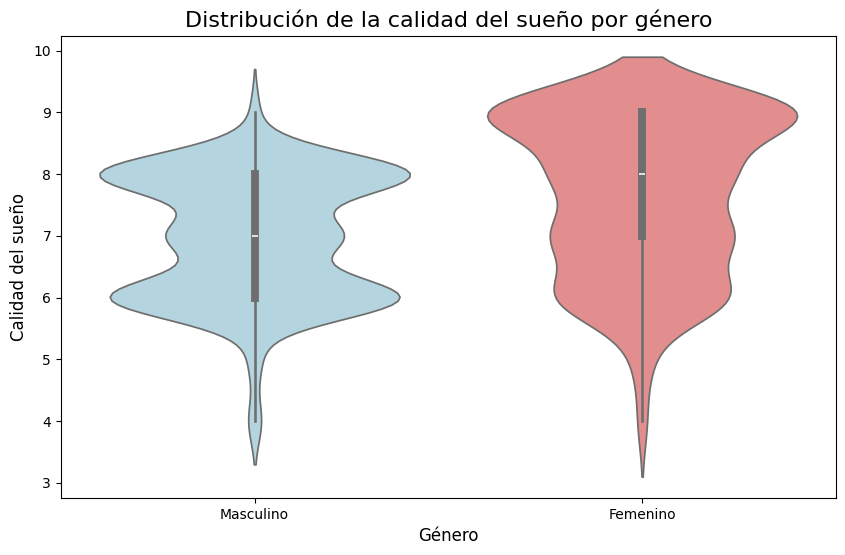

In [44]:

color_palette = {'Masculino': 'lightblue', 'Femenino': 'lightcoral'}

plt.figure(figsize=(10, 6))
sns.violinplot(x='Gender', y='Quality of Sleep', data=sleep_df, palette=color_palette)
plt.title('Distribución de la calidad del sueño por género', fontsize=16)
plt.xlabel('Género', fontsize=12)
plt.ylabel('Calidad del sueño', fontsize=12)
plt.savefig('quality_of_sleep_by_gender.pdf')
plt.show()

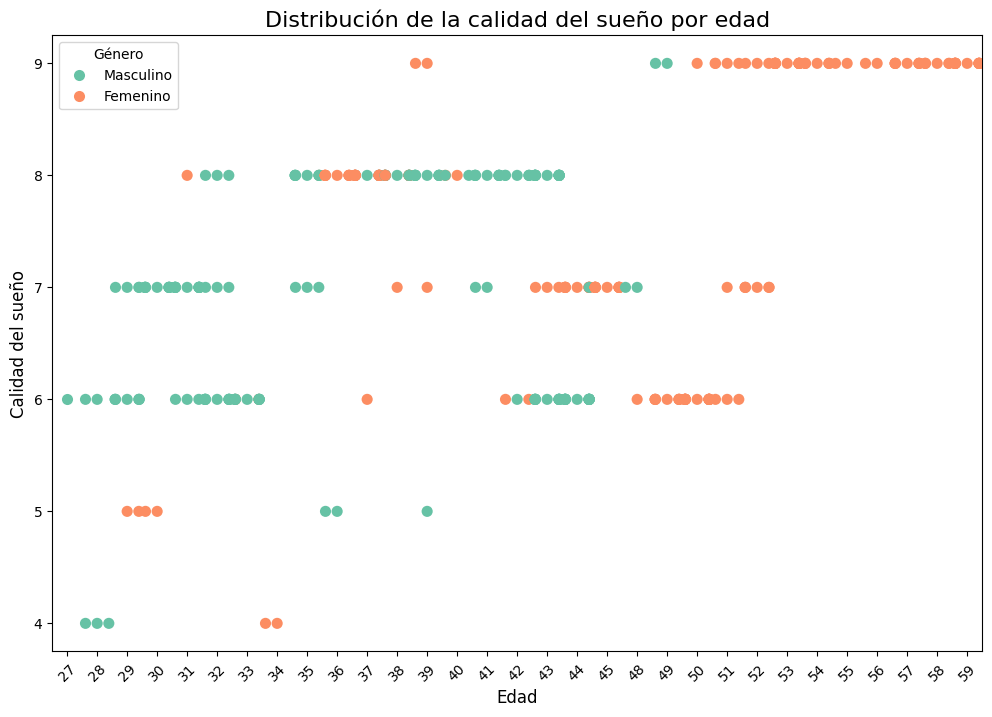

In [45]:
color_palette = sns.color_palette('Set2')
plt.figure(figsize=(12, 8))
sns.swarmplot(x='Age', 
              y='Quality of Sleep', 
              hue='Gender', 
              data=sleep_df, 
              palette=color_palette, 
              size=8)
plt.title('Distribución de la calidad del sueño por edad', fontsize=16)
plt.xlabel('Edad', fontsize=12)
plt.ylabel('Calidad del sueño', fontsize=12)
plt.legend(title='Género', fontsize=10)
plt.xticks(rotation=45)
plt.savefig('quality_of_sleep_by_age.pdf')
plt.show()

In [46]:

fig = px.scatter(
    sleep_df,
    x='Daily Steps',
    y='Gender',
    color='Gender',
    title='Relación entre los pasos diarios y el género',
    labels={
        'Daily Steps': 'Pasos diarios',
        'Gender': 'Género'
    }
)

fig.write_image(
    "daily_steps_vs_gender.pdf",
    width=800,
    height=600
)

fig.show()

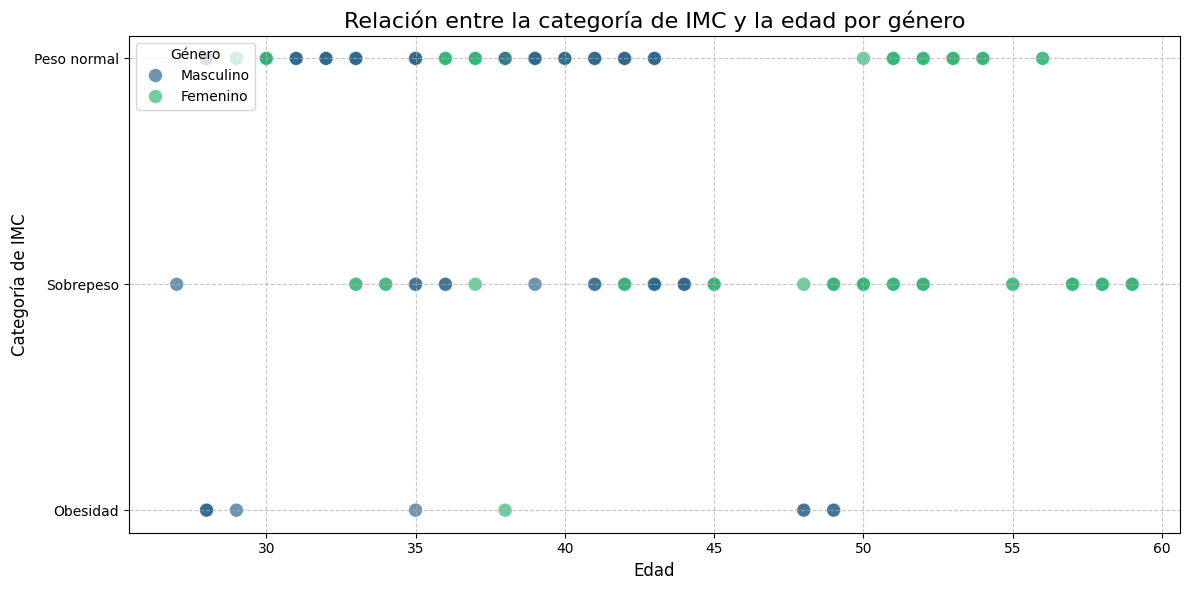

In [47]:

sleep_df['BMI Category'] = sleep_df['BMI Category'].replace({
    'Underweight': 'Bajo peso',
    'Normal': 'Peso normal',
    'Normal Weight': 'Peso normal',
    'Overweight': 'Sobrepeso',
    'Obese': 'Obesidad'
})


orden_bmi = ['Bajo peso', 'Peso normal', 'Sobrepeso', 'Obesidad']

sleep_df['BMI Category'] = pd.Categorical(
    sleep_df['BMI Category'],
    categories=orden_bmi,
    ordered=True
)


plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=sleep_df,
    x='Age',
    y='BMI Category',
    hue='Gender',
    palette='viridis',
    s=100,
    edgecolor='w',
    alpha=0.7,
    linewidth=0.5
)


plt.title(
    'Relación entre la categoría de IMC y la edad por género',
    fontsize=16
)
plt.xlabel('Edad', fontsize=12)
plt.ylabel('Categoría de IMC', fontsize=12)
plt.legend(title='Género', fontsize=10, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()


plt.savefig('bmi_category_vs_age.pdf')
plt.show()

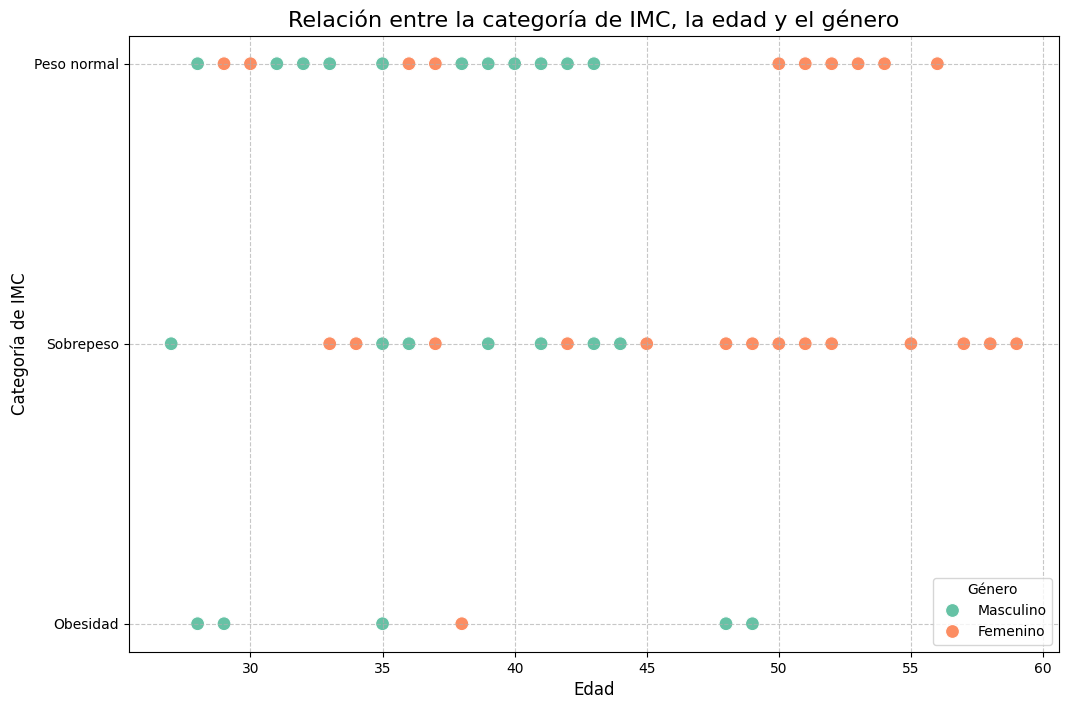

In [48]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    x='Age',
    y='BMI Category',
    hue='Gender',
    data=sleep_df,
    palette=color_palette,
    s=100
)

plt.title('Relación entre la categoría de IMC, la edad y el género', fontsize=16)
plt.xlabel('Edad', fontsize=12)
plt.ylabel('Categoría de IMC', fontsize=12)
plt.legend(title='Género', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)

plt.savefig('categoria_imc_edad_genero.pdf')
plt.show()


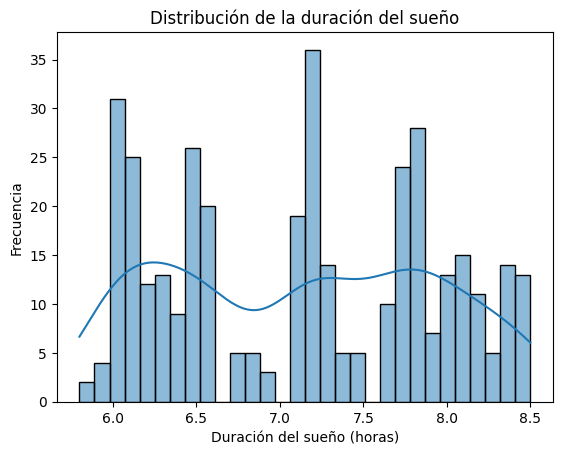

In [49]:
sns.histplot(sleep_df['Sleep Duration'], bins=30, kde=True)

plt.title('Distribución de la duración del sueño')
plt.xlabel('Duración del sueño (horas)')
plt.ylabel('Frecuencia')

plt.savefig('distribucion_duracion_sueno.pdf')
plt.show()


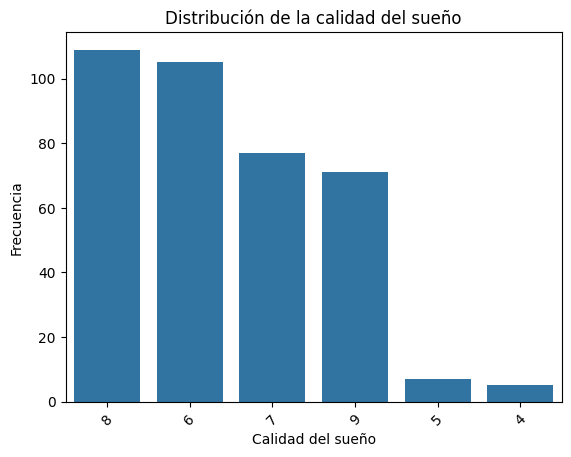

In [50]:
sns.countplot(
    x='Quality of Sleep',
    data=sleep_df,
    order=sleep_df['Quality of Sleep'].value_counts().index
)

plt.title('Distribución de la calidad del sueño')
plt.xlabel('Calidad del sueño')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)

plt.savefig('distribucion_calidad_sueno.pdf')
plt.show()



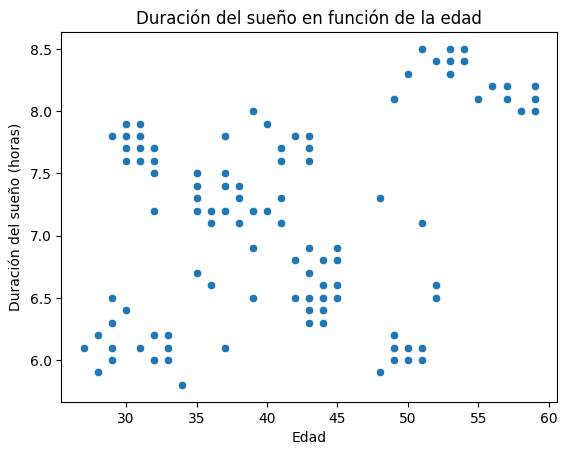

In [51]:
sns.scatterplot(
    x='Age',
    y='Sleep Duration',
    data=sleep_df
)

plt.title('Duración del sueño en función de la edad')
plt.xlabel('Edad')
plt.ylabel('Duración del sueño (horas)')

plt.savefig('duracion_sueno_por_edad.pdf')
plt.show()


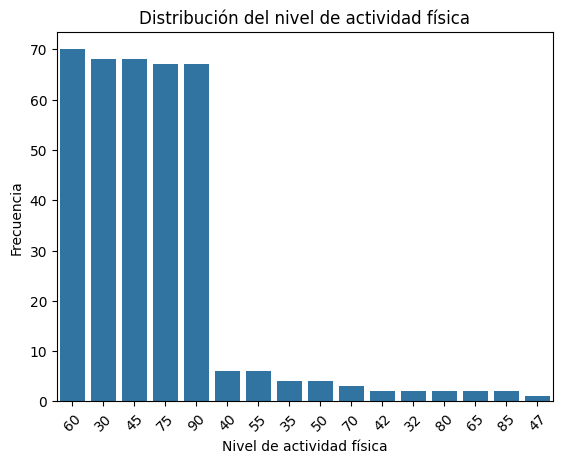

In [52]:
sns.countplot(
    x='Physical Activity Level',
    data=sleep_df,
    order=sleep_df['Physical Activity Level'].value_counts().index
)

plt.title('Distribución del nivel de actividad física')
plt.xlabel('Nivel de actividad física')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)

plt.savefig('distribucion_nivel_actividad_fisica.pdf')
plt.show()


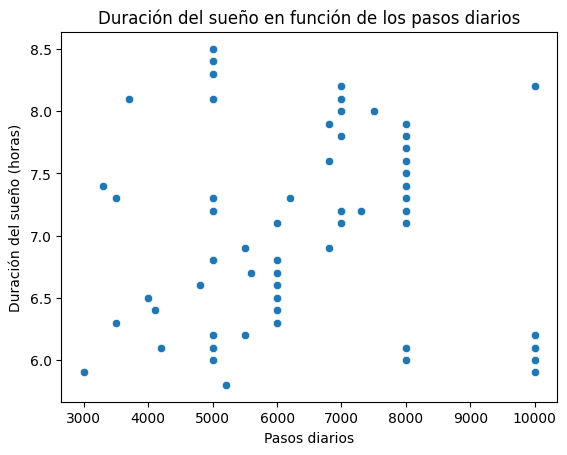

In [53]:
sns.scatterplot(
    x='Daily Steps',
    y='Sleep Duration',
    data=sleep_df
)

plt.title('Duración del sueño en función de los pasos diarios')
plt.xlabel('Pasos diarios')
plt.ylabel('Duración del sueño (horas)')

plt.savefig('duracion_sueno_por_pasos_diarios.pdf')
plt.show()


In [54]:
fig = px.pie(
    sleep_df,
    names='Stress Level',
    title='Distribución del nivel de estrés'
)

fig.write_image(
    "distribucion_nivel_estres.pdf",
    width=800,
    height=600
)

fig.show()


In [55]:

sleep_df = sleep_df.rename(columns={
    'Age': 'Edad',
    'Gender': 'Género',
    'BMI Category': 'Categoría de IMC',
    'Sleep Duration': 'Duración del sueño (horas)',
    'Quality of Sleep': 'Calidad del sueño',
    'Physical Activity Level': 'Nivel de actividad física',
    'Daily Steps': 'Pasos diarios',
    'Stress Level': 'Nivel de estrés',
    'Heart Rate': 'Frecuencia cardíaca'
})

fig = px.bar(
    sleep_df,
    x='Nivel de estrés',
    y='Calidad del sueño',
    color='Nivel de estrés',
    title='Relación entre el nivel de estrés y la calidad del sueño'
)

fig.write_image(
    "nivel_estres_vs_calidad_sueno.pdf",
    width=800,
    height=600
)

fig.show()



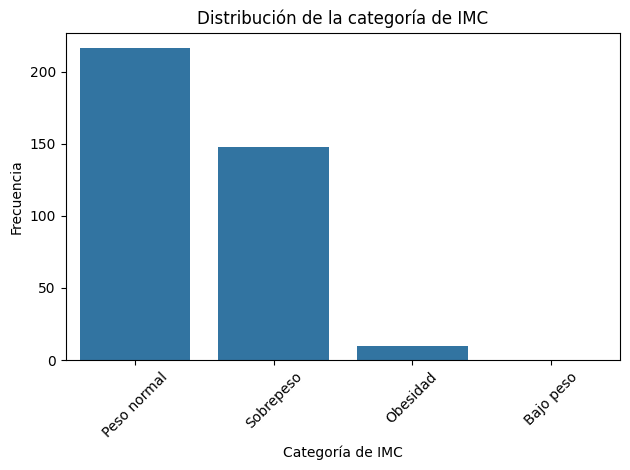

In [56]:
sns.countplot(
    x='Categoría de IMC',
    data=sleep_df,
    order=sleep_df['Categoría de IMC'].value_counts().index
)

plt.title('Distribución de la categoría de IMC')
plt.xlabel('Categoría de IMC')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('distribucion_categoria_imc.pdf')
plt.show()


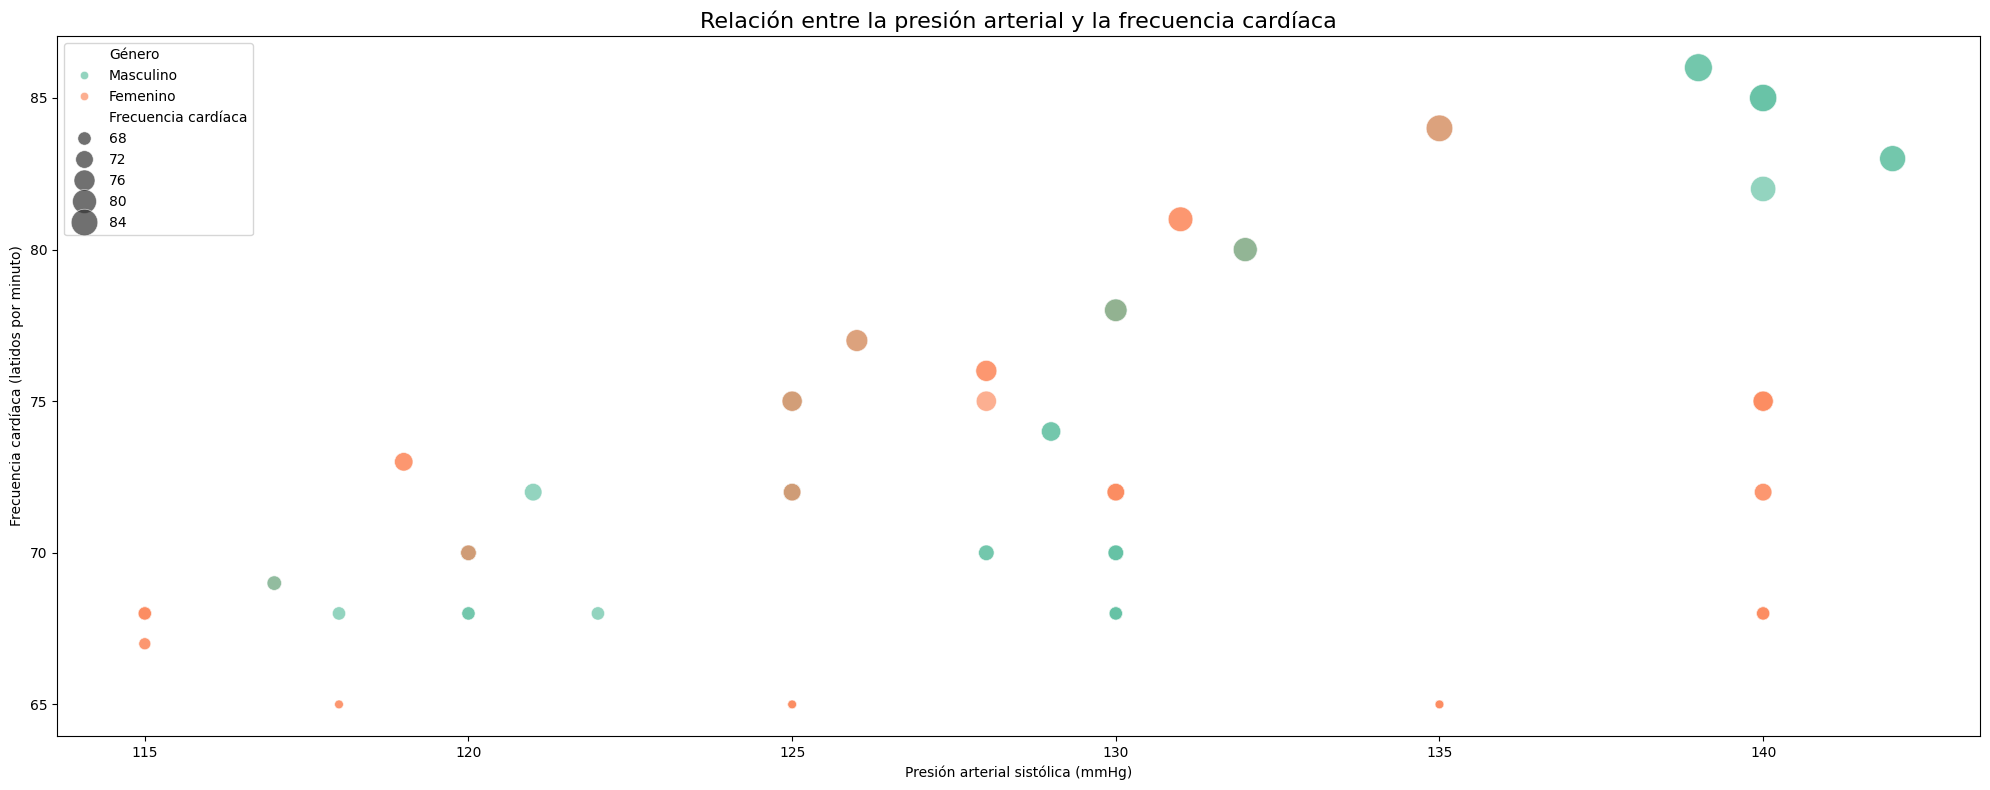

In [57]:

sleep_df['Blood Pressure'] = (
    sleep_df['Blood Pressure']
    .astype(str)
    .str.split('/')
    .str[0]
    .astype(float)
)


sleep_df['Heart Rate'] = pd.to_numeric(
    sleep_df['Frecuencia cardíaca'],
    errors='coerce'
)


sleep_df = sleep_df.dropna(
    subset=['Blood Pressure', 'Heart Rate', 'Género']
)


plt.figure(figsize=(20, 8))

sns.scatterplot(
    data=sleep_df,
    x='Blood Pressure',
    y='Heart Rate',
    hue='Género',
    size='Frecuencia cardíaca',          
    sizes=(40, 400),           
    palette='Set2',
    alpha=0.7,
    edgecolor='w'
)

plt.xlabel("Presión arterial sistólica (mmHg)")
plt.ylabel("Frecuencia cardíaca (latidos por minuto)")
plt.title(
    "Relación entre la presión arterial y la frecuencia cardíaca",
    fontsize=16
)

plt.tight_layout()


plt.savefig("blood_pressure_vs_heart_rate.pdf")
plt.show()

In [58]:
import pandas as pd

df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")

df = df.rename(columns={
    'Quality of Sleep': 'Calidad_Sueno',
    'Stress Level': 'Estres',
    'Daily Steps': 'Pasos_Diarios',
    'Age': 'Edad',
    'BMI': 'IMC',
    'Heart Rate': 'Frecuencia_Cardiaca'
})

variables = [
    'Calidad_Sueno',
    'Estres',
    'Pasos_Diarios',
    'Edad',
    'Frecuencia_Cardiaca'
]



In [59]:
print(df.columns)


Index(['Person ID', 'Gender', 'Edad', 'Occupation', 'Sleep Duration',
       'Calidad_Sueno', 'Physical Activity Level', 'Estres', 'BMI Category',
       'Blood Pressure', 'Frecuencia_Cardiaca', 'Pasos_Diarios',
       'Sleep Disorder'],
      dtype='object')


In [60]:
descriptivos = df[variables].agg(['mean', 'std']).T
descriptivos.columns = ['Media', 'Desviacion_Estandar']
descriptivos



,Media,Desviacion_Estandar
Calidad_Sueno,7.312834,1.196956
Estres,5.385027,1.774526
Pasos_Diarios,6816.844920,1617.915679
Edad,42.184492,8.673133
Frecuencia_Cardiaca,70.165775,4.135676


In [61]:
matriz_correlacion = df[variables].corr(method='pearson')
matriz_correlacion


,Calidad_Sueno,Estres,Pasos_Diarios,Edad,Frecuencia_Cardiaca
Calidad_Sueno,1.000000,-0.898752,0.016791,0.473734,-0.659865
Estres,-0.898752,1.000000,0.186829,-0.422344,0.670026
Pasos_Diarios,0.016791,0.186829,1.000000,0.057973,-0.030309
Edad,0.473734,-0.422344,0.057973,1.000000,-0.225606
Frecuencia_Cardiaca,-0.659865,0.670026,-0.030309,-0.225606,1.000000


In [62]:
corr_sueno = matriz_correlacion['Calidad_Sueno']

tabla_resultados = descriptivos.copy()
tabla_resultados['r_con_Calidad_Sueno'] = corr_sueno

# Eliminar autocorrelación
tabla_resultados = tabla_resultados.drop('Calidad_Sueno')

tabla_resultados.round(3)


,Media,Desviacion_Estandar,r_con_Calidad_Sueno
Estres,5.385,1.775,-0.899
Pasos_Diarios,6816.845,1617.916,0.017
Edad,42.184,8.673,0.474
Frecuencia_Cardiaca,70.166,4.136,-0.660
